# IMDB movies dataset
In this assignment, you will analyze data on movies from the website IMDB.com.
Data is available for download from this link - https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset

Import the relevant packages:

In [103]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

Import the dataset:

In [104]:
import kagglehub

path = kagglehub.dataset_download("carolzhangdc/imdb-5000-movie-dataset")
df = pd.read_csv(os.path.join(path, "movie_metadata.csv"))

How many records and columns were imported?

In [105]:
df.shape

(5043, 28)

Show the first 5 rows:

In [106]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


Let's study which columns have missing values. First, show a heatmap of columns with missing values.  
Note that for better visibility, we transpose the matrix so that the column names become the rows in the heatmap, using the `.T` operator.

<Axes: >

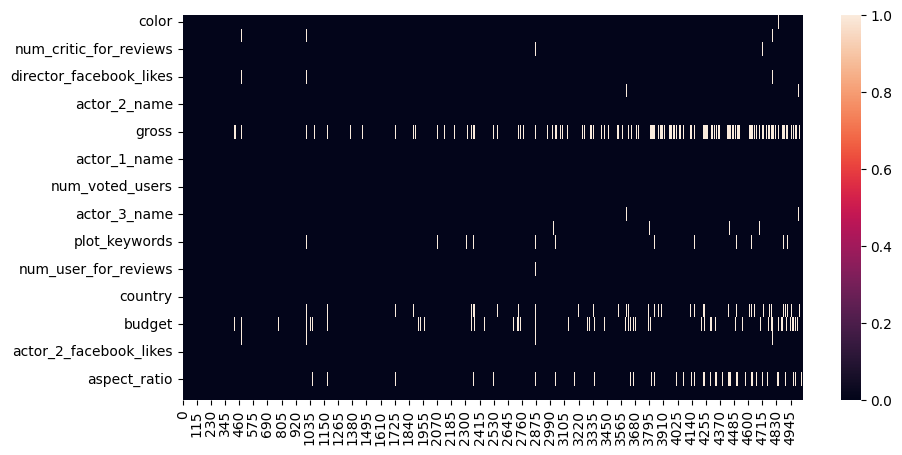

In [107]:
sns.heatmap(df.isnull().T.astype(int))

We can also review the number of missing values as a Series - sort the values using `sort_values()`

In [108]:
df.isnull().sum().sort_values(ascending=False)

gross                        884
budget                       492
aspect_ratio                 329
content_rating               303
plot_keywords                153
title_year                   108
director_name                104
director_facebook_likes      104
num_critic_for_reviews        50
actor_3_name                  23
actor_3_facebook_likes        23
num_user_for_reviews          21
color                         19
duration                      15
language                      14
facenumber_in_poster          13
actor_2_name                  13
actor_2_facebook_likes        13
actor_1_name                   7
actor_1_facebook_likes         7
country                        5
cast_total_facebook_likes      0
num_voted_users                0
movie_title                    0
movie_imdb_link                0
genres                         0
imdb_score                     0
movie_facebook_likes           0
dtype: int64

For movies released since 1990, do Color movies make more money than Black and White ones?

<Axes: xlabel='color', ylabel='gross'>

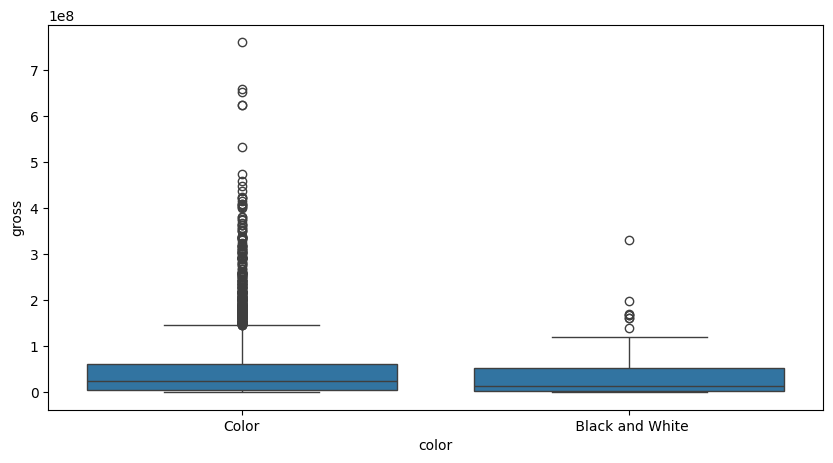

In [109]:
sns.boxplot(data=df[df.title_year >= 1990], x='color', y='gross')

It's hard to see the values here, so let's show the Y axis in Millions of Dollars and zoom the Y-axis to 0-200.

(0.0, 200.0)

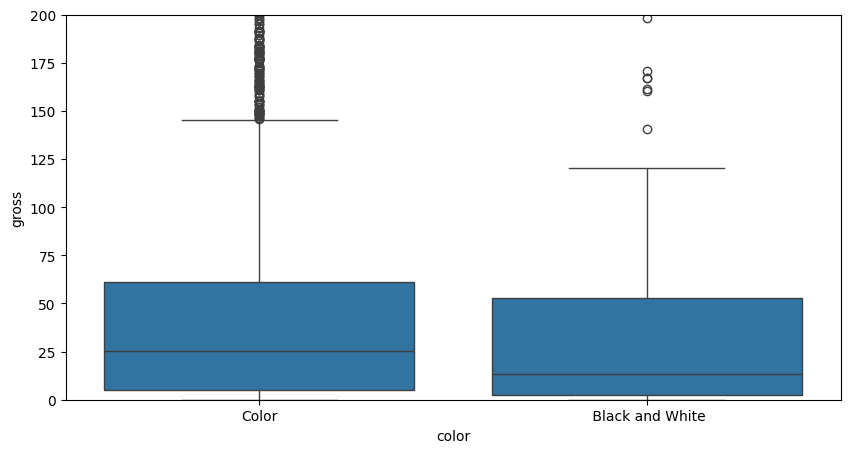

In [110]:
sns.boxplot(data=df[df.title_year >= 1990], x='color', y=df['gross'] / 1e6)
plt.ylim((0, 200))

Show the 5 directors that have the highest movie rating and at least 30% of their movies are in Black and White.

In [111]:
df['is_bw'] = (df['color'] == ' Black and White').astype(int)
df_director = df.groupby('director_name')[['is_bw', 'imdb_score']].mean().sort_values('is_bw', ascending=False)
df_director[df_director.is_bw > 0.3].sort_values('imdb_score', ascending=False).head()

,is_bw,imdb_score
director_name,,
Charles Chaplin,1.0,8.6
Moustapha Akkad,1.0,8.4
Robert Mulligan,1.0,8.4
Fritz Lang,1.0,8.3
David Sington,1.0,8.1


Let's compute a `decade` folder:

In [112]:
df['decade'] = np.floor((df['title_year'] - 1900) / 10)

For each decade, show the 5 directors who made the highest gross revenues (i.e. the directors whose movies, summed together, had the highest gross revenues).

In [113]:
df['gross_mm'] = df['gross'] / 1e6
df_director_decade = df.groupby(['decade', 'director_name'])['gross_mm'].sum().reset_index().sort_values(['decade', 'gross_mm'], ascending=[True, False])
result = df_director_decade.groupby('decade').head(5).copy()
result['decade'] = result['decade'].apply(lambda x: f"{int(1900 + x * 10)}s")
result

,decade,director_name,gross_mm
0,1910s,D.W. Griffith,0.000000
4,1920s,Harry F. Millarde,3.000000
3,1920s,Harry Beaumont,2.808000
1,1920s,Fritz Lang,0.026435
2,1920s,Georg Wilhelm Pabst,0.009950
5,1920s,King Vidor,0.000000
16,1930s,Victor Fleming,220.857890
17,1930s,William Cottrell,184.925485
14,1930s,Mark Sandrich,3.000000
12,1930s,Lloyd Bacon,2.300000


Do short movies (50-70 minutes) tend to get higher or lower rating than medium length (80-110 minutes) and long movies (130-200 minutes)?  

First, write a function that returns the labels `'short'`, `'medium'`, `'long'` or `None` for a row based on its duration. Then use `apply()` to create a new column called `movie_duration_group`.

In [114]:
def get_duration_group(x):
    if x >= 50 and x <= 70:
        return 'short'
    if x >= 80 and x <= 110:
        return 'medium'
    if x >= 130 and x <= 200:
        return 'long'
    return None

df['movie_duration_group'] = df['duration'].apply(get_duration_group)

<Axes: xlabel='movie_duration_group', ylabel='gross'>

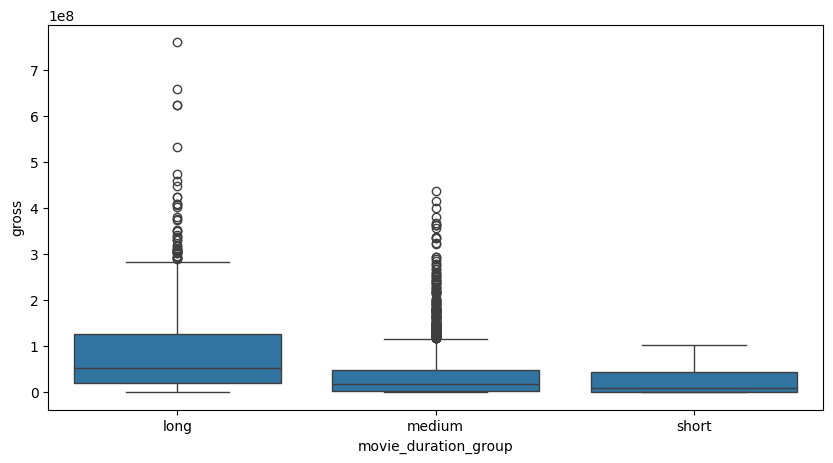

In [115]:
sns.boxplot(data=df, x='movie_duration_group', y='gross')

Is there a correlation between the number of words in a movie's title and its success in the box office, its rating, or its duration?

In [116]:
df['num_words_in_movie_title'] = df['movie_title'].apply(lambda x: len(x.split()))
df[['movie_title', 'num_words_in_movie_title']].head()

,movie_title,num_words_in_movie_title
0,Avatar,1
1,Pirates of the Caribbean: At World's End,7
2,Spectre,1
3,The Dark Knight Rises,4
4,Star Wars: Episode VII - The Force Awakens ...,8


<Axes: xlabel='num_words_in_movie_title', ylabel='gross'>

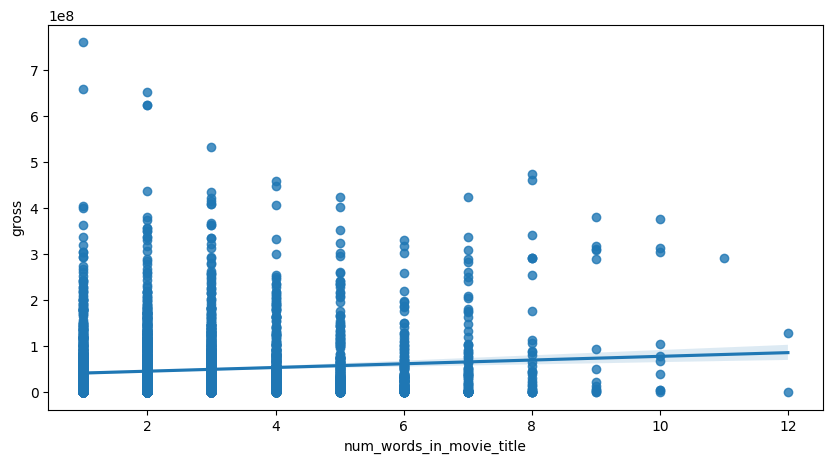

In [117]:
sns.regplot(data=df, x='num_words_in_movie_title', y='gross')

<Axes: xlabel='num_words_in_movie_title', ylabel='imdb_score'>

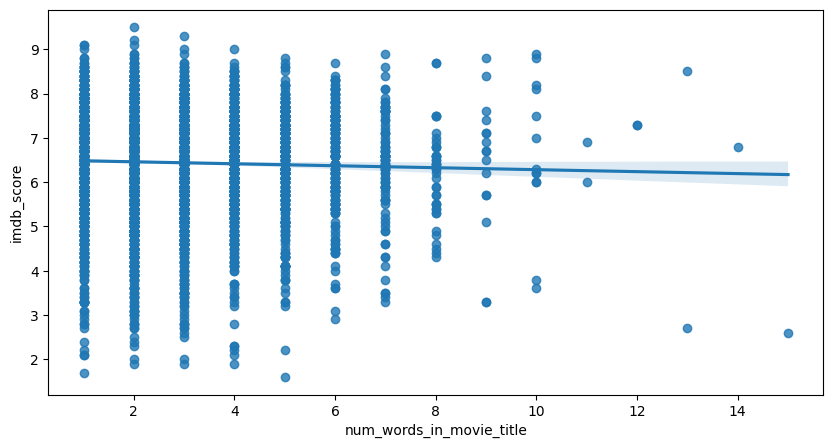

In [118]:
sns.regplot(data=df, x='num_words_in_movie_title', y='imdb_score')

<Axes: xlabel='num_words_in_movie_title', ylabel='duration'>

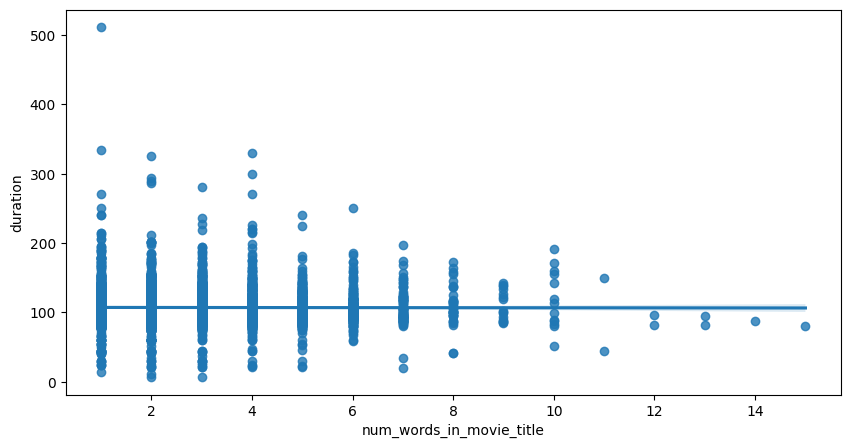

In [119]:
sns.regplot(data=df, x='num_words_in_movie_title', y='duration')

What are the highest grossing genres?

Note that the genres column contains multiple genres. Let's first create a new dataframe, where each movie appears multiple times, with each of its genres. You can iterate over the rows of the dataframe, to create a new dataframe with the index of the movie and its genre (so there's a different row for each of the genres of a movie).

In [120]:
df_genres = []
for i, r in df.iterrows():
    for genre in r['genres'].split('|'):
        df_genres.append((i, genre))

df_genres = pd.DataFrame(df_genres, columns=['index', 'genre']).set_index('index')
df_genres.head()

,genre
index,
0,Action
0,Adventure
0,Fantasy
0,Sci-Fi
1,Action


Next, use `pd.merge()` to merge the new dataframe that you've created (with a row for each genre) and the original dataframe that contains metadata about a movie.

In [121]:
df_genres = pd.merge(left=df, right=df_genres, left_index=True, right_index=True)
df_genres.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,is_bw,decade,gross_mm,movie_duration_group,num_words_in_movie_title,genre
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,936.0,7.9,1.78,33000,0,10.0,760.505847,long,1,Action
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,936.0,7.9,1.78,33000,0,10.0,760.505847,long,1,Adventure
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,936.0,7.9,1.78,33000,0,10.0,760.505847,long,1,Fantasy
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,936.0,7.9,1.78,33000,0,10.0,760.505847,long,1,Sci-Fi
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,5000.0,7.1,2.35,0,0,10.0,309.404152,long,7,Action


Now you can compute the average gross value for each genre, in $M.

In [122]:
df_genres.groupby('genre')['gross'].mean().sort_values(ascending=False).head(10) / 1e6

genre
Animation    106.954239
Adventure     98.405188
Family        89.302305
Fantasy       85.447070
Sci-Fi        82.244106
Action        76.289889
Musical       53.146879
Comedy        47.683480
Thriller      46.890572
Mystery       44.445346
Name: gross, dtype: float64

What year was the best year for movies in terms of rating? of gross revenues? What are the top 5 movies from that year?

In [123]:
df.groupby('title_year')['imdb_score'].mean().sort_values(ascending=False).head()

title_year
1957.0    8.550000
1925.0    8.300000
1927.0    8.300000
1960.0    8.233333
1934.0    8.200000
Name: imdb_score, dtype: float64

In [124]:
df[df.title_year == 1957].sort_values('imdb_score', ascending=False).head()['movie_title']

4822                    12 Angry Men 
4066    The Bridge on the River Kwai 
Name: movie_title, dtype: object

In [125]:
df.groupby('title_year')['gross'].mean().sort_values(ascending=False).head() / 1e6

title_year
1937.0    184.925485
1975.0    124.409732
1939.0    110.428945
1977.0    106.290809
1973.0    102.919529
Name: gross, dtype: float64

In [126]:
df[df.title_year == 1937].sort_values('gross', ascending=False).head()['movie_title']

4449    Snow White and the Seven Dwarfs 
2904              The Prisoner of Zenda 
Name: movie_title, dtype: object

What movie genres tend to re-occur?

To solve this, use the merged dataframe with a different row for each genre. Use the function `pd.crosstab` to create a matrix where each row is a movie, and the columns are the different genres. The values of the matrix will be 1 if the movie belongs to the genre and 0 otherwise.

In [127]:
df_genres = df_genres.reset_index()
z = pd.crosstab(index=df_genres['index'], columns=[df_genres.genre])
z.head()

genre,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,War,Western
index,,,,,,,,,,,,,,,,,,,,,
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now you can compute the co-occurrence matrix using dot product on the matrix you've just created.

In [128]:
z.T.dot(z)

genre,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,War,Western
genre,,,,,,,,,,,,,,,,,,,,,
Action,1153,470,46,20,255,328,3,345,81,177,...,84,0,0,104,336,0,26,589,64,30
Adventure,470,923,169,22,311,49,4,242,290,285,...,53,0,0,112,262,1,13,224,41,30
Animation,46,169,242,3,172,6,1,32,205,115,...,8,0,0,20,51,0,6,8,4,3
Biography,20,22,3,293,29,48,15,275,8,3,...,1,0,0,56,0,0,44,32,31,6
Comedy,255,311,172,29,1872,254,14,663,358,251,...,47,0,1,589,158,2,70,133,20,17
Crime,328,49,6,48,254,889,8,526,16,15,...,157,1,0,97,27,0,6,548,6,14
Documentary,3,4,1,15,14,8,121,13,2,1,...,1,3,0,0,1,1,10,1,9,0
Drama,345,242,32,275,663,526,13,2594,139,156,...,260,1,1,737,149,0,124,697,190,56
Family,81,290,205,8,358,16,2,139,546,229,...,22,0,0,87,78,1,30,11,2,5


Show a heatmap of co-occurrences:

<Axes: xlabel='genre', ylabel='genre'>

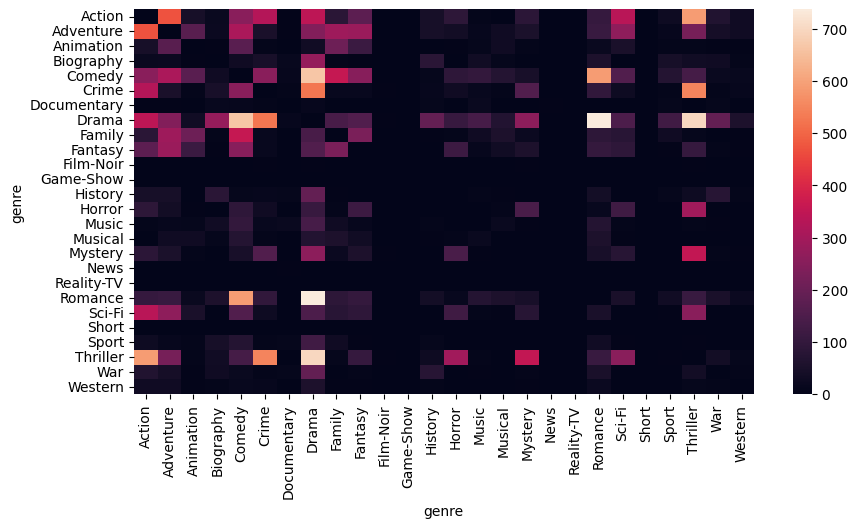

In [129]:
co_matrix = z.T.dot(z)
np.fill_diagonal(co_matrix.values, 0)
sns.heatmap(co_matrix)

Do movies actually become longer through the years, or is it just me?

Use the median. Show a boxplot for the decades, and a print of the values for each year.

<Axes: xlabel='decade', ylabel='duration'>

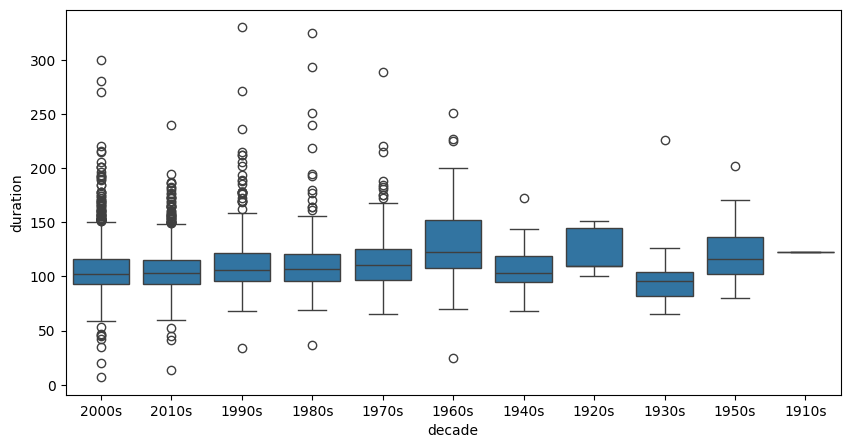

In [130]:
decade_labels = df['decade'].apply(lambda x: f"{int(1900 + x * 10)}s" if pd.notna(x) else None)
sns.boxplot(data=df.assign(decade=decade_labels), x='decade', y='duration')

In [131]:
df.groupby('title_year')['duration'].median()

title_year
1916.0    123.0
1920.0    110.0
1925.0    151.0
1927.0    145.0
1929.0    105.0
          ...  
2012.0    101.0
2013.0    105.0
2014.0    102.0
2015.0    103.0
2016.0    107.5
Name: duration, Length: 91, dtype: float64

When is the best time of the year to release a movie?  
Analyze this dataset - https://raw.githubusercontent.com/nirupamaprv/Investigate_Dataset/master/data_imdb.csv

Study several different aspects of the time that you find interesting, e.g. the month, day of the month, day of the week etc.

Output of the results isn't given here, so you experiment yourself!

C:\Users\Yonatan\AppData\Local\Temp\ipykernel_27064\1310284729.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['release_date'] = pd.to_datetime(df2['release_date'])


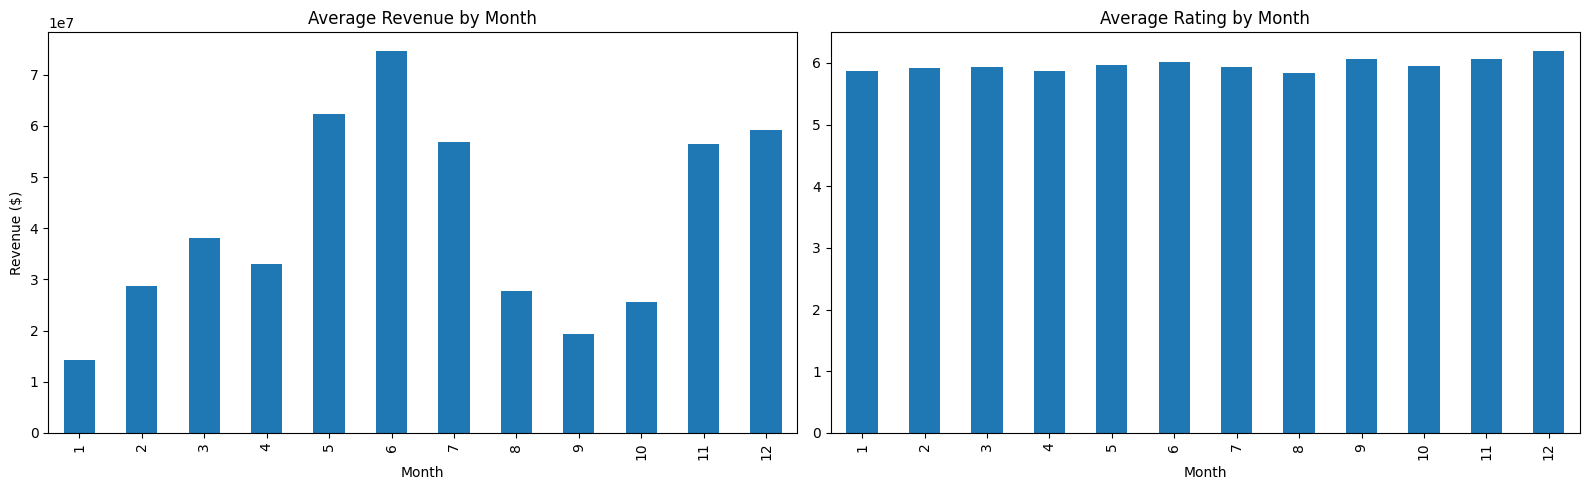

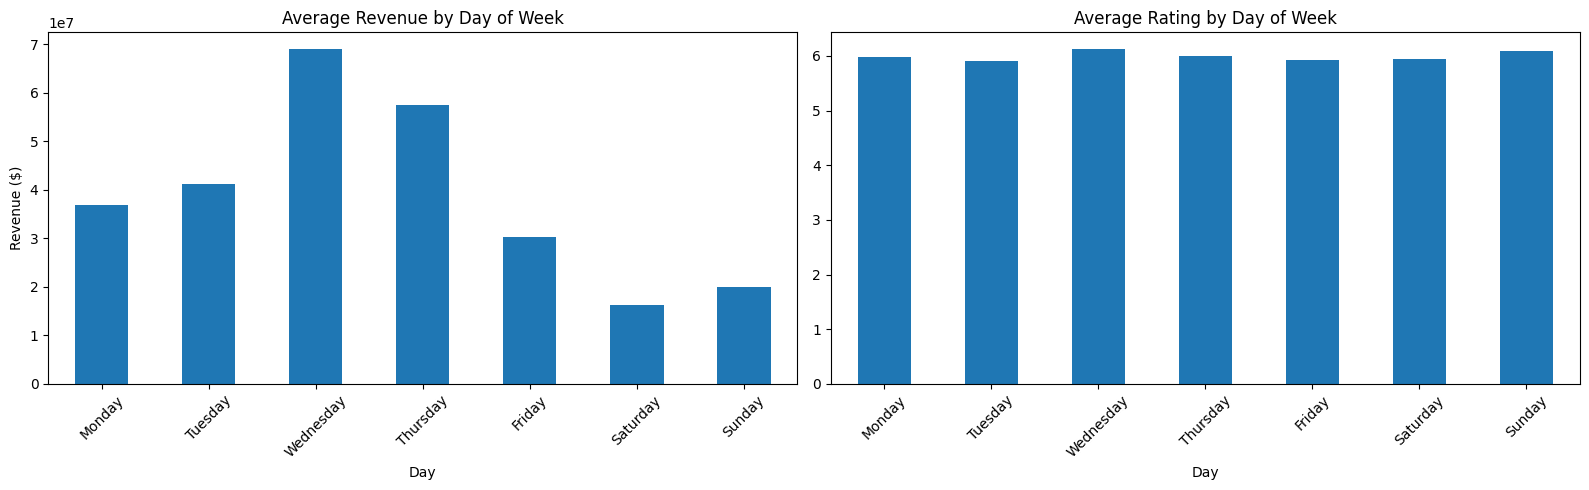

In [132]:
df2 = pd.read_csv('https://raw.githubusercontent.com/nirupamaprv/Investigate_Dataset/master/data_imdb.csv')
df2['release_date'] = pd.to_datetime(df2['release_date'])
df2['month'] = df2['release_date'].dt.month
df2['day_of_week'] = df2['release_date'].dt.dayofweek
df2['day_name'] = df2['release_date'].dt.day_name()

# --- Month graphs ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df2.groupby('month')['revenue'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Revenue by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue ($)')

df2.groupby('month')['vote_average'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Rating by Month')
axes[1].set_xlabel('Month')
plt.tight_layout()
plt.show()

# --- Day of week graphs ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df2.groupby('day_name')['revenue'].mean().reindex(day_order).plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

df2.groupby('day_name')['vote_average'].mean().reindex(day_order).plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Rating by Day of Week')
axes[1].set_xlabel('Day')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Do different genres tend to be released in different times of the year?

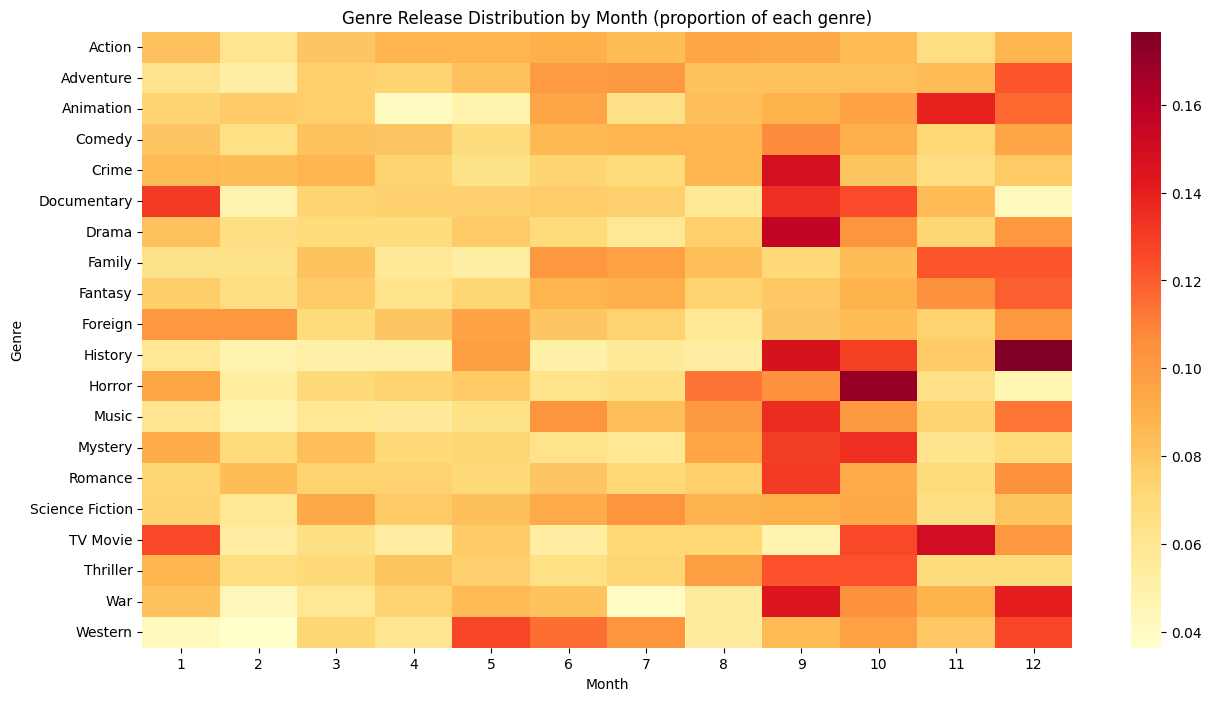

In [133]:
df2_genres = []
for i, r in df2.iterrows():
    if pd.notna(r['genres']):
        for genre in str(r['genres']).split('|'):
            df2_genres.append({'month': r['month'], 'genre': genre.strip()})

df2_genres = pd.DataFrame(df2_genres)

genre_month = df2_genres.groupby(['genre', 'month']).size().unstack(fill_value=0)
genre_month_pct = genre_month.div(genre_month.sum(axis=1), axis=0)

plt.figure(figsize=(15, 8))
sns.heatmap(genre_month_pct, cmap='YlOrRd', annot=False)
plt.title('Genre Release Distribution by Month (proportion of each genre)')
plt.xlabel('Month')
plt.ylabel('Genre')
plt.show()

Build a regressor that tries to rating of a movie from the other parameters. Assess the performance of your model and analyze where it tends to fail.

Rows after outlier removal: 3282
Test RMSE: 0.789


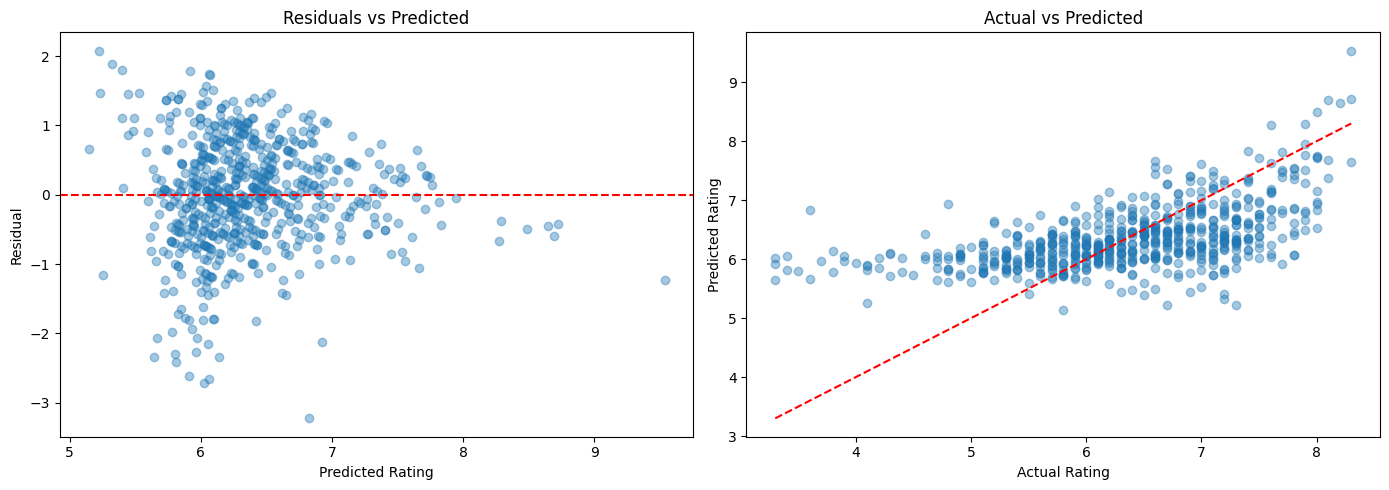


Feature coefficients:
title_year                -1.620054e-02
duration                   1.468722e-02
gross_mm                  -3.384149e-03
num_critic_for_reviews     1.565602e-03
num_user_for_reviews      -7.684625e-04
actor_3_facebook_likes    -2.130262e-04
director_facebook_likes    1.317163e-04
actor_2_facebook_likes     1.697506e-05
num_voted_users            6.040094e-06
movie_facebook_likes       7.082204e-07
actor_1_facebook_likes     4.160740e-07
budget                    -3.917427e-09
dtype: float64


In [134]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy import stats

features = ['duration', 'director_facebook_likes', 'actor_1_facebook_likes',
            'actor_2_facebook_likes', 'actor_3_facebook_likes',
            'num_critic_for_reviews', 'num_user_for_reviews',
            'num_voted_users', 'movie_facebook_likes', 'gross_mm',
            'title_year', 'budget']

df_model = df[features + ['imdb_score']].dropna()

# Remove rows where any feature or target has a z-score > 3
z_scores = np.abs(stats.zscore(df_model))
df_model = df_model[(z_scores < 3).all(axis=1)]
print(f'Rows after outlier removal: {len(df_model)}')

X = df_model[features]
y = df_model['imdb_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE: {rmse:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
axes[0].scatter(y_pred, residuals, alpha=0.4)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, y_pred, alpha=0.4)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('Actual vs Predicted')

plt.tight_layout()
plt.show()

coef_df = pd.Series(model.coef_, index=features).sort_values(key=abs, ascending=False)
print('\nFeature coefficients:')
print(coef_df)

### KNN Regressor

KNN Test RMSE (k=10): 0.764


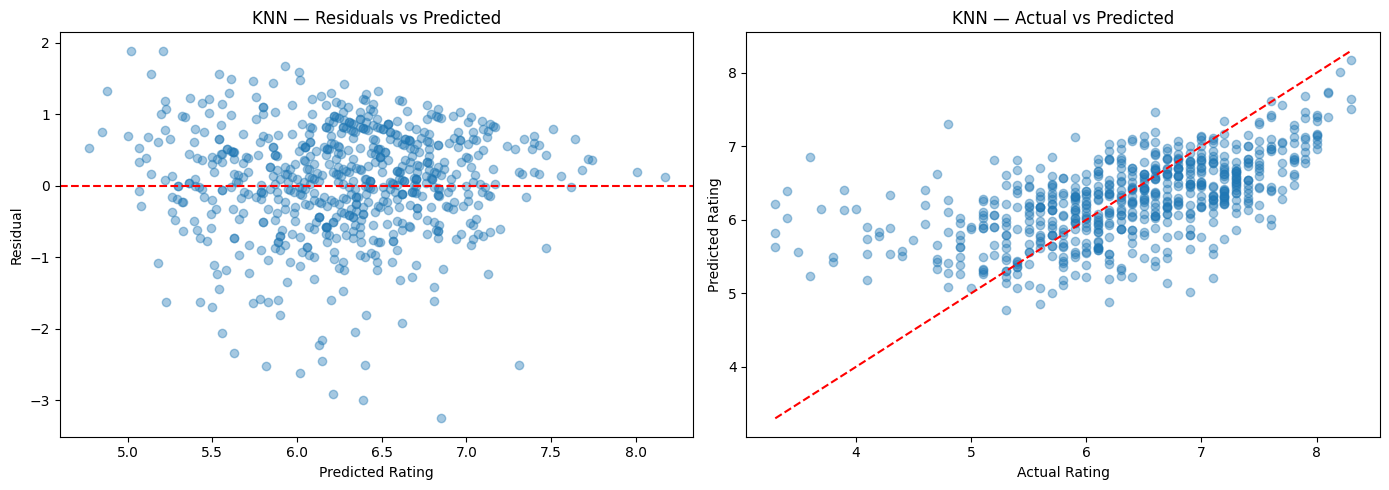

In [135]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
print(f'KNN Test RMSE (k=10): {rmse_knn:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_knn = y_test - y_pred_knn
axes[0].scatter(y_pred_knn, residuals_knn, alpha=0.4)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Residual')
axes[0].set_title('KNN — Residuals vs Predicted')

axes[1].scatter(y_test, y_pred_knn, alpha=0.4)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('KNN — Actual vs Predicted')

plt.tight_layout()
plt.show()

## Good job!